# Simulate Cost Notebook

Run the cells in order. This notebook stores the raw simulated data and the summary results for every scenario.

In [24]:
import os
import random

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy.optimize import minimize_scalar

## Parameters And Storage

Paper notation used here:

- `alpha` = demand uncertainty
- `beta` = estimate uncertainty

This cell creates the main objects you can work with later:

- `scenario_data`: raw `D` and `E` for each scenario
- `summary_rows`: summary numbers before turning them into a table
- `scenario_table`: tidy table created later
- `total_cost_matrix`: 4x4 matrix for the heatmap
- `estimate_samples_matrix`: 4x4 stored `E` samples for the histograms

In [25]:
# Parameters
ITERATIONS = 10000
SHORTFALL_COST = 5.0  # c^s

# In the paper notation:
# alpha = demand uncertainty
# beta = estimate uncertainty
UNCERTAINTY_LEVELS = {
    "none": 0.0,
    "low": 0.25,
    "med": 0.5,
    "high": 0.75,
}
SEED = 123

levels = list(UNCERTAINTY_LEVELS.keys())
total_cost_matrix = [[0.0 for _ in levels] for _ in levels]
estimate_samples_matrix = [[None for _ in levels] for _ in levels]

# Main storage objects
scenario_data = {}
summary_rows = []

os.makedirs("Figures", exist_ok=True)

## Run Simulation And Store Everything

This cell simulates `D` and `E`, optimizes `S`, and stores both the raw samples and the expected costs.

In the equations from the paper:

- `D ~ LogNormal(-alpha^2 / 2, alpha^2)`
- `E = D * LogNormal(-beta^2 / 2, beta^2)`

In [26]:
header = (
    f"{'Demand':<6} {'Estimate':<8} "
    f"{'Exp inv cost':>14} {'Exp short cost':>16} {'Exp total cost':>16}"
)
print(header)
print("-" * len(header))

scenario_data.clear()
summary_rows.clear()
total_cost_matrix = [[0.0 for _ in levels] for _ in levels]
estimate_samples_matrix = [[None for _ in levels] for _ in levels]

for demand_label, demand_sigma in UNCERTAINTY_LEVELS.items():
    for estimate_label, estimate_sigma in UNCERTAINTY_LEVELS.items():
        rng = random.Random(f"{SEED}:{demand_label}:{estimate_label}")

        alpha = demand_sigma
        beta = estimate_sigma

        D = []
        E = []

        for _ in range(ITERATIONS):
            if alpha == 0:
                demand = 1.0
            else:
                demand_mu = -0.5 * alpha * alpha
                demand = rng.lognormvariate(demand_mu, alpha)

            if beta == 0:
                estimate_noise = 1.0
            else:
                estimate_mu = -0.5 * beta * beta
                estimate_noise = rng.lognormvariate(estimate_mu, beta)

            estimate = demand * estimate_noise

            D.append(demand)
            E.append(estimate)

        result = minimize_scalar(
            lambda S: S + SHORTFALL_COST * sum(max(e - S, 0.0) for e in E) / ITERATIONS,
            bounds=(0.0, max(E)),
            method="bounded",
        )

        S = result.x
        expected_investment_cost = S
        expected_shortfall_cost = SHORTFALL_COST * sum(max(e - S, 0.0) for e in E) / ITERATIONS
        expected_total_cost = expected_investment_cost + expected_shortfall_cost
        expected_demand_shortfall_cost = SHORTFALL_COST * sum(max(d - S, 0.0) for d in D) / ITERATIONS
        expected_demand_total_cost = expected_investment_cost + expected_demand_shortfall_cost

        row_index = levels.index(demand_label)
        col_index = levels.index(estimate_label)
        total_cost_matrix[row_index][col_index] = expected_total_cost
        estimate_samples_matrix[row_index][col_index] = E.copy()

        scenario_data[(demand_label, estimate_label)] = {
            "alpha": alpha,
            "beta": beta,
            "D": D.copy(),
            "E": E.copy(),
            "optimal_S": S,
            "expected_investment_cost": expected_investment_cost,
            "expected_shortfall_cost": expected_shortfall_cost,
            "expected_total_cost": expected_total_cost,
            "expected_demand_shortfall_cost": expected_demand_shortfall_cost,
            "expected_demand_total_cost": expected_demand_total_cost,
        }

        summary_rows.append({
            "demand_level": demand_label,
            "estimate_level": estimate_label,
            "alpha": alpha,
            "beta": beta,
            "optimal_S": S,
            "expected_investment_cost": expected_investment_cost,
            "expected_shortfall_cost": expected_shortfall_cost,
            "expected_total_cost": expected_total_cost,
            "expected_demand_shortfall_cost": expected_demand_shortfall_cost,
            "expected_demand_total_cost": expected_demand_total_cost,
        })

        print(
            f"{demand_label:<6} "
            f"{estimate_label:<8} "
            f"{expected_investment_cost:>14.4f} "
            f"{expected_shortfall_cost:>16.4f} "
            f"{expected_total_cost:>16.4f}"
        )

Demand Estimate   Exp inv cost   Exp short cost   Exp total cost
----------------------------------------------------------------
none   none             1.0000           0.0000           1.0000
none   low              1.1991           0.1864           1.3855
none   med              1.3238           0.4909           1.8147
none   high             1.4178           0.8825           2.3003
low    none             1.1920           0.1907           1.3827
low    low              1.2695           0.3146           1.5841
low    med              1.3644           0.5856           1.9500
low    high             1.4403           0.9944           2.4347
med    none             1.3431           0.4904           1.8335
med    low              1.3554           0.6091           1.9645
med    med              1.4193           0.8090           2.2283
med    high             1.4049           1.1802           2.5851
high   none             1.4166           0.8724           2.2891
high   low              1

## Inspect Stored Data

These cells let you play with the stored results directly.

In [27]:
scenario_table = pd.DataFrame(summary_rows)
scenario_table

,demand_level,estimate_level,alpha,beta,optimal_S,expected_investment_cost,expected_shortfall_cost,expected_total_cost,expected_demand_shortfall_cost,expected_demand_total_cost
0,none,none,0.00,0.00,0.999994,0.999994,0.000030,1.000024,0.000030,1.000024
1,none,low,0.00,0.25,1.199091,1.199091,0.186419,1.385510,0.000000,1.199091
2,none,med,0.00,0.50,1.323786,1.323786,0.490873,1.814659,0.000000,1.323786
3,none,high,0.00,0.75,1.417756,1.417756,0.882533,2.300289,0.000000,1.417756
4,low,none,0.25,0.00,1.191950,1.191950,0.190734,1.382684,0.190734,1.382684
5,low,low,0.25,0.25,1.269462,1.269462,0.314645,1.584107,0.131255,1.400717
6,low,med,0.25,0.50,1.364420,1.364420,0.585625,1.950045,0.077560,1.441980
7,low,high,0.25,0.75,1.440282,1.440282,0.994437,2.434719,0.052609,1.492891
8,med,none,0.50,0.00,1.343085,1.343085,0.490369,1.833455,0.490369,1.833455
9,med,low,0.50,0.25,1.355357,1.355357,0.609117,1.964475,0.476783,1.832140


In [28]:
list(scenario_data.keys())

[('none', 'none'),
 ('none', 'low'),
 ('none', 'med'),
 ('none', 'high'),
 ('low', 'none'),
 ('low', 'low'),
 ('low', 'med'),
 ('low', 'high'),
 ('med', 'none'),
 ('med', 'low'),
 ('med', 'med'),
 ('med', 'high'),
 ('high', 'none'),
 ('high', 'low'),
 ('high', 'med'),
 ('high', 'high')]

In [29]:
scenario_data[("low", "high")]

{'alpha': 0.25,
 'beta': 0.75,
 'D': [0.7433053866674507,
  0.8769589631742419,
  1.3484322220141924,
  0.8887233895553637,
  1.3941293047952965,
  1.4506864488150564,
  0.7281127109895692,
  0.9275247864727324,
  1.0930233869052401,
  0.6104861859899156,
  1.2467599766566022,
  1.2655870897876917,
  1.6964551348501806,
  1.0065475047523689,
  0.9490809054902879,
  0.7224205189259081,
  1.1666806319406855,
  0.6971900214594519,
  1.3182876100058798,
  1.0323410208386394,
  1.8261320747199483,
  0.8039325633976147,
  0.7107959724887595,
  1.2167529698474258,
  0.9066194901428972,
  0.8765640016366562,
  0.8396161747415126,
  0.9957989922894561,
  0.7146513347152799,
  1.1068989514566832,
  0.8758544785000978,
  0.7343812142664535,
  0.7801350520093032,
  1.2797850257261598,
  0.9875989275236364,
  1.0370411442353902,
  1.1691433378007225,
  0.829597340968385,
  0.8265530591326417,
  1.0707147376761506,
  0.8407933162868226,
  0.990120249325071,
  0.9978395288131824,
  0.7785035563264953

In [30]:
scenario_data[("low", "high")]["D"][:10], scenario_data[("low", "high")]["E"][:10]

([0.7433053866674507,
  0.8769589631742419,
  1.3484322220141924,
  0.8887233895553637,
  1.3941293047952965,
  1.4506864488150564,
  0.7281127109895692,
  0.9275247864727324,
  1.0930233869052401,
  0.6104861859899156],
 [0.9938252367597843,
  2.392681747142458,
  5.588515006178675,
  0.4137119288237977,
  0.3695149674828789,
  0.33835273072757505,
  2.628549849376079,
  0.7277415903294848,
  1.7066645896511952,
  0.5796487214763663])

## Plots

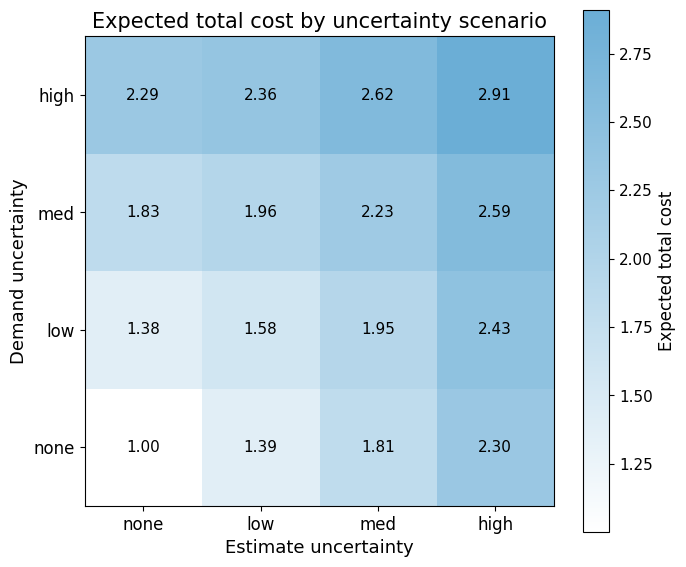

In [31]:
cmap = LinearSegmentedColormap.from_list("white_to_blue", ["#ffffff", "#6baed6"])

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(total_cost_matrix, origin="lower", cmap=cmap)

ax.set_xticks(range(len(levels)))
ax.set_yticks(range(len(levels)))
ax.set_xticklabels(levels)
ax.set_yticklabels(levels)
ax.set_xlabel("Estimate uncertainty", fontsize=13, color="black")
ax.set_ylabel("Demand uncertainty", fontsize=13, color="black")
ax.set_title("Expected total cost by uncertainty scenario", fontsize=15, color="black")
ax.tick_params(axis="both", labelsize=12, colors="black")

for row_index in range(len(levels)):
    for col_index in range(len(levels)):
        value = total_cost_matrix[row_index][col_index]
        ax.text(col_index, row_index, f"{value:.2f}", ha="center", va="center", fontsize=11, color="black")

colorbar = plt.colorbar(image, ax=ax)
colorbar.set_label("Expected total cost", fontsize=12, color="black")
colorbar.ax.tick_params(labelsize=11, colors="black")

plt.tight_layout()
plt.savefig("Figures/expected_total_cost_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

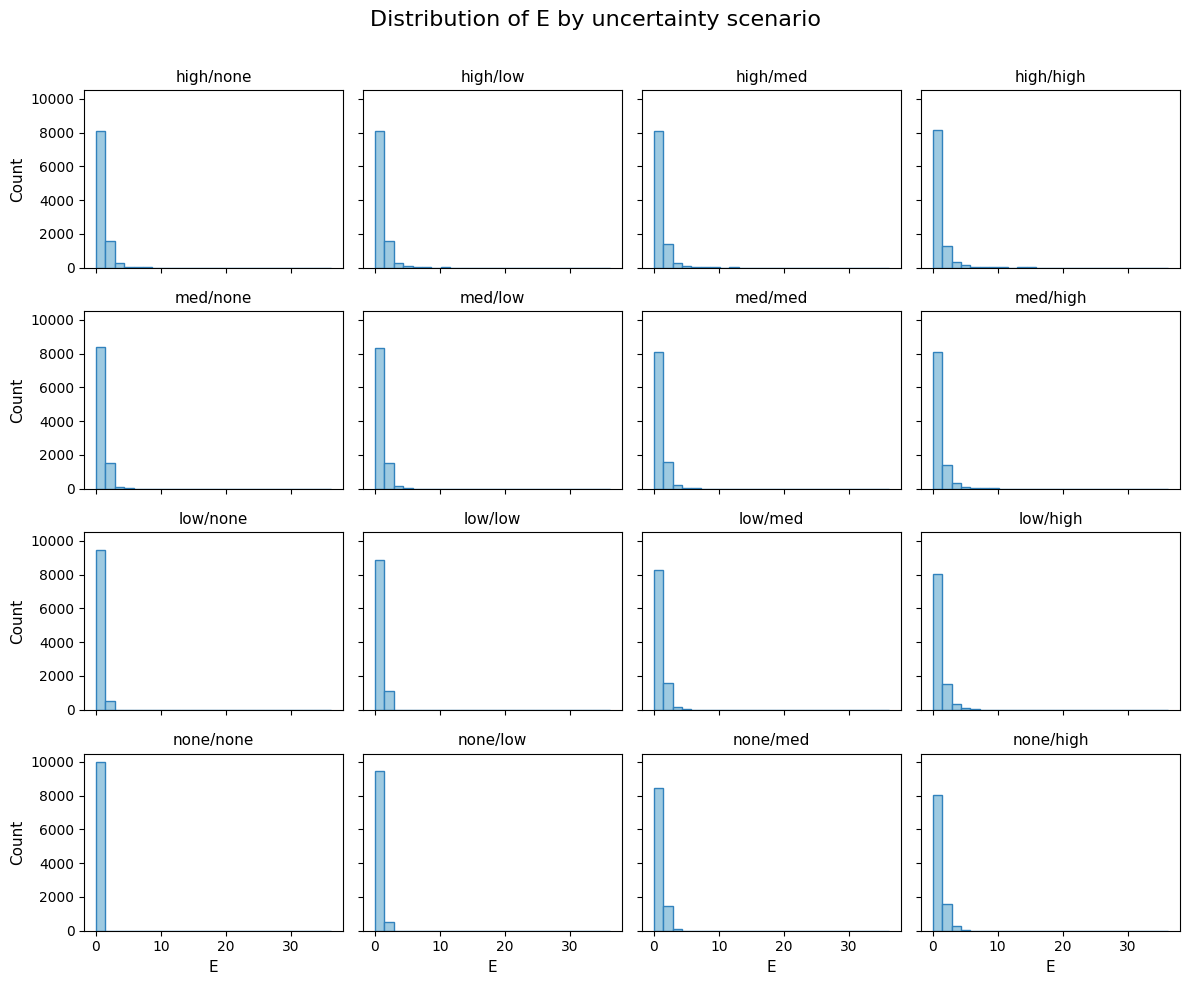

In [32]:
all_E_values = []
for row in estimate_samples_matrix:
    for samples in row:
        all_E_values.extend(samples)

global_max_E = max(all_E_values)

fig, axes = plt.subplots(len(levels), len(levels), figsize=(12, 10), sharex=True, sharey=True)

for row_index in range(len(levels)):
    for col_index in range(len(levels)):
        plot_row = len(levels) - 1 - row_index
        ax = axes[plot_row][col_index]
        E_values = estimate_samples_matrix[row_index][col_index]

        ax.hist(
            E_values,
            bins=25,
            range=(0.0, global_max_E),
            color="#9ecae1",
            edgecolor="#3182bd",
        )
        ax.set_title(f"{levels[row_index]}/{levels[col_index]}", fontsize=11, color="black")

        if plot_row == len(levels) - 1:
            ax.set_xlabel("E", fontsize=11, color="black")
        if col_index == 0:
            ax.set_ylabel("Count", fontsize=11, color="black")
        ax.tick_params(axis="both", labelsize=10, colors="black")

fig.suptitle("Distribution of E by uncertainty scenario", fontsize=16, color="black")
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.savefig("Figures/estimate_histogram_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Estimate-Based Cost Composition Matrix

This plot colors each scenario by expected total cost and also shows the expected investment cost and estimate-based shortfall cost, both as values and as shares of the total.

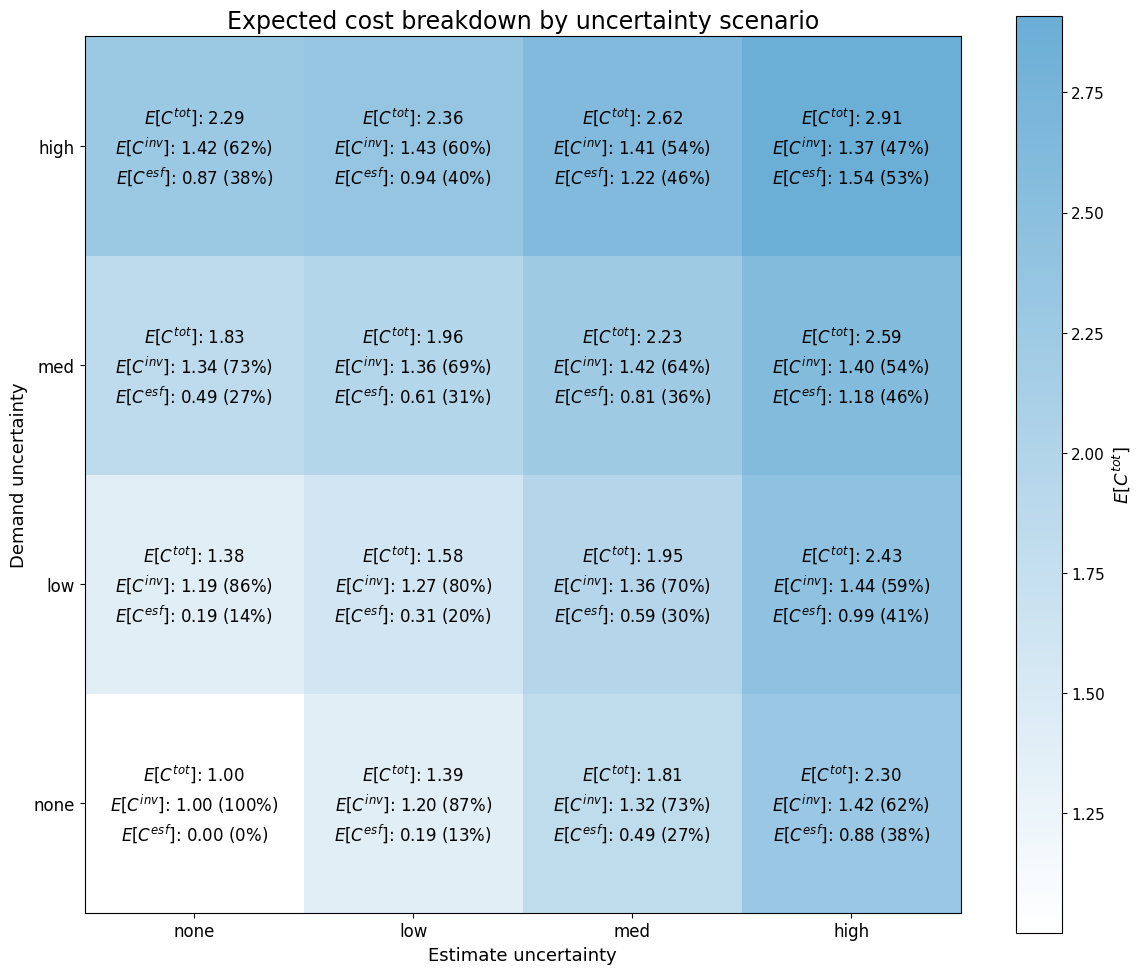

In [33]:
total_cost_plot = [[0.0 for _ in levels] for _ in levels]
investment_cost_plot = [[0.0 for _ in levels] for _ in levels]
shortfall_cost_plot = [[0.0 for _ in levels] for _ in levels]

for _, row in scenario_table.iterrows():
    row_index = levels.index(row["demand_level"])
    col_index = levels.index(row["estimate_level"])
    total_cost_plot[row_index][col_index] = row["expected_total_cost"]
    investment_cost_plot[row_index][col_index] = row["expected_investment_cost"]
    shortfall_cost_plot[row_index][col_index] = row["expected_shortfall_cost"]

cmap = LinearSegmentedColormap.from_list("white_to_blue", ["#ffffff", "#6baed6"])

fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(total_cost_plot, origin="lower", cmap=cmap)

ax.set_xticks(range(len(levels)))
ax.set_yticks(range(len(levels)))
ax.set_xticklabels(levels)
ax.set_yticklabels(levels)
ax.set_xlabel("Estimate uncertainty", fontsize=13, color="black")
ax.set_ylabel("Demand uncertainty", fontsize=13, color="black")
ax.set_title("Expected Cost Composition Across Uncertainty Scenarios: Estimate-Based Shortfall", fontsize=17, color="black")
ax.tick_params(axis="both", labelsize=12, colors="black")

for row_index in range(len(levels)):
    for col_index in range(len(levels)):
        total_value = total_cost_plot[row_index][col_index]
        investment_value = investment_cost_plot[row_index][col_index]
        shortfall_value = shortfall_cost_plot[row_index][col_index]
        investment_share = 100 * investment_value / total_value
        shortfall_share = 100 * shortfall_value / total_value

        label = (
            f"$E[C^{{tot}}]$: {total_value:.2f}\n"
            f"$E[C^{{inv}}]$: {investment_value:.2f} ({investment_share:.0f}%)\n"
            f"$E[C^{{esf}}]$: {shortfall_value:.2f} ({shortfall_share:.0f}%)"
        )

        ax.text(
            col_index,
            row_index,
            label,
            ha="center",
            va="center",
            fontsize=12,
            color="black",
            linespacing=1.4,
        )

colorbar = plt.colorbar(image, ax=ax)
colorbar.set_label(r"$E[C^{tot}]$", fontsize=13, color="black")
colorbar.ax.tick_params(labelsize=11, colors="black")

plt.tight_layout()
plt.savefig("Figures/expected_cost_breakdown_matrix.pdf", bbox_inches="tight")
plt.show()

## Demand-Based Cost Composition Matrix

This plot has the same style, but it uses the real demand shortfall cost
$E[C^{dsf}] = c^s (D - S)^+$
instead of the estimate-based shortfall cost.

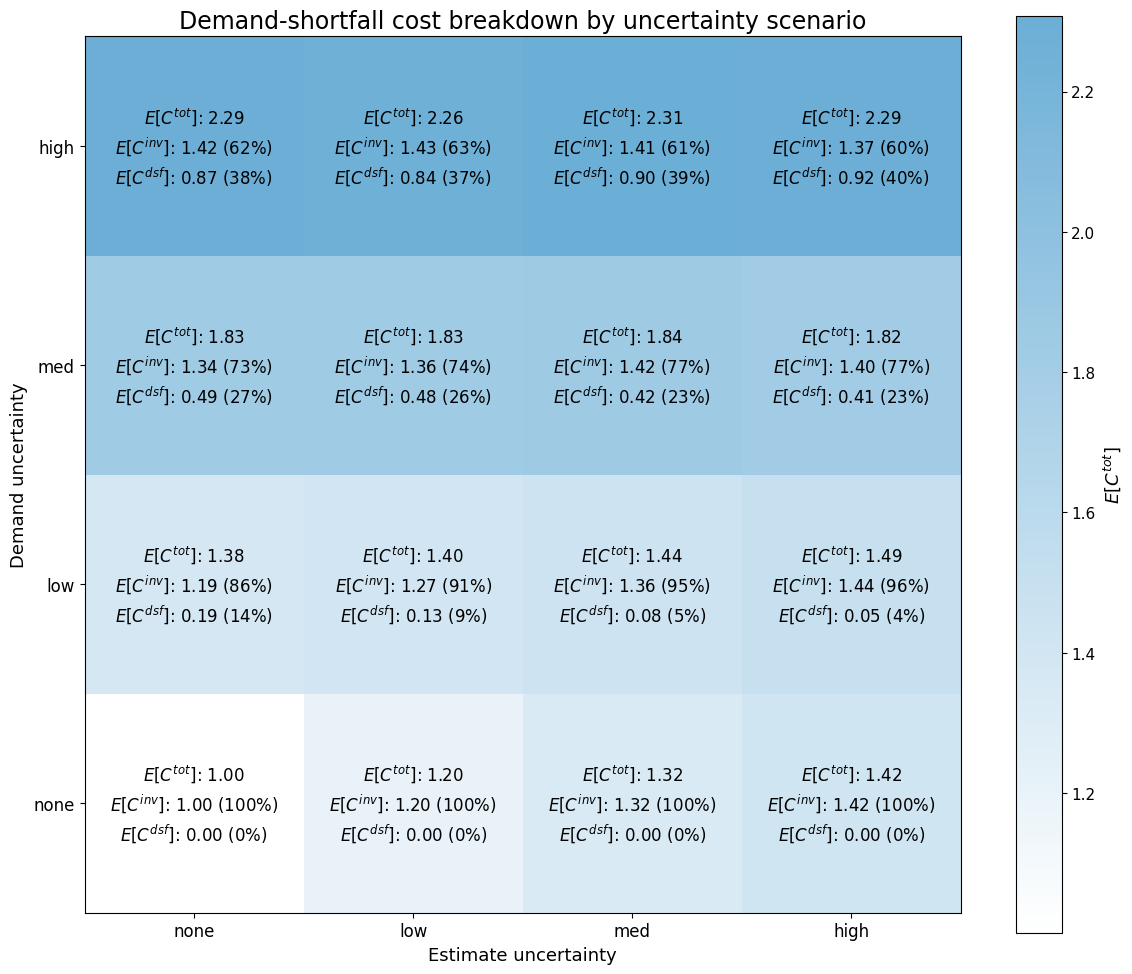

In [34]:
demand_total_cost_plot = [[0.0 for _ in levels] for _ in levels]
investment_cost_plot = [[0.0 for _ in levels] for _ in levels]
demand_shortfall_cost_plot = [[0.0 for _ in levels] for _ in levels]

for _, row in scenario_table.iterrows():
    row_index = levels.index(row["demand_level"])
    col_index = levels.index(row["estimate_level"])
    demand_total_cost_plot[row_index][col_index] = row["expected_demand_total_cost"]
    investment_cost_plot[row_index][col_index] = row["expected_investment_cost"]
    demand_shortfall_cost_plot[row_index][col_index] = row["expected_demand_shortfall_cost"]

cmap = LinearSegmentedColormap.from_list("white_to_blue", ["#ffffff", "#6baed6"])

fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(demand_total_cost_plot, origin="lower", cmap=cmap)

ax.set_xticks(range(len(levels)))
ax.set_yticks(range(len(levels)))
ax.set_xticklabels(levels)
ax.set_yticklabels(levels)
ax.set_xlabel("Estimate uncertainty", fontsize=13, color="black")
ax.set_ylabel("Demand uncertainty", fontsize=13, color="black")
ax.set_title("Expected Cost Composition Across Uncertainty Scenarios: Demand-Based Shortfall", fontsize=17, color="black")
ax.tick_params(axis="both", labelsize=12, colors="black")

for row_index in range(len(levels)):
    for col_index in range(len(levels)):
        total_value = demand_total_cost_plot[row_index][col_index]
        investment_value = investment_cost_plot[row_index][col_index]
        demand_shortfall_value = demand_shortfall_cost_plot[row_index][col_index]
        investment_share = 100 * investment_value / total_value
        demand_shortfall_share = 100 * demand_shortfall_value / total_value

        label = (
            f"$E[C^{{tot}}]$: {total_value:.2f}\n"
            f"$E[C^{{inv}}]$: {investment_value:.2f} ({investment_share:.0f}%)\n"
            f"$E[C^{{dsf}}]$: {demand_shortfall_value:.2f} ({demand_shortfall_share:.0f}%)"
        )

        ax.text(
            col_index,
            row_index,
            label,
            ha="center",
            va="center",
            fontsize=12,
            color="black",
            linespacing=1.4,
        )

colorbar = plt.colorbar(image, ax=ax)
colorbar.set_label(r"$E[C^{tot}]$", fontsize=13, color="black")
colorbar.ax.tick_params(labelsize=11, colors="black")

plt.tight_layout()
plt.savefig("Figures/expected_demand_shortfall_breakdown_matrix.pdf", bbox_inches="tight")
plt.show()